# Copernicus Climate Data Store (CDS) access using xcube

This notebook provides a walk-through demonstrating how to use xcube and the xcube Climate Data Store (CDS) plugin to read and explore [Land cover classification gridded maps from 1992 to present derived from satellite observations](https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview).

Before using this notebook, ensure that you have set up xcube, the CDS plugin, and Jupyter Lab as described in the [Ex0-CDS-store-Setup](./Ex0-CDS-store-setup.ipynb) notebook.

First, we import some necessary libraries.

In [1]:
from xcube.core.maskset import MaskSet
from xcube.core.store import new_data_store

Create a CDS data store object. The optional `normalize_names` parameter specifies that variable names in returned data cubes will be converted to legal Python identifiers, if required.

In [2]:
cds_store = new_data_store("cds", normalize_names=True)

Find out which datasets are available from this store. We pick `"satellite-land-cover"`.

In [3]:
data_ids = list(cds_store.get_data_ids())
data_ids

['reanalysis-era5-single-levels:ensemble_mean',
 'reanalysis-era5-single-levels:ensemble_members',
 'reanalysis-era5-single-levels:ensemble_spread',
 'reanalysis-era5-single-levels:reanalysis',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_ensemble_members',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels-timeseries',
 'reanalysis-era5-land-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-land',
 'satellite-soil-moisture:saturation:daily',
 'satellite-soil-moisture:saturation:10-day',
 'satellite-soil-moisture:saturation:monthly',
 'satellite-soil-moisture:volumetric:daily',
 'satellite-soil-moisture:volumetric:10-day',
 'satellite-soil-moisture:volumetric:monthly',
 'satellite-sea-ice-thickness:envisat',
 'satellite-sea-ice-thickness:cryosat-2',
 'derived-drought-historical-monthly:reanalysis',
 'derived-drought-historical-monthly:ensemble_members',
 'satellite-land-cover']

In [4]:
data_id = "satellite-land-cover"

Let's see what parameters we can specify when opening the dataset. We can specify `time_range` and `bbox`, where `time_range` is a required parameter. 

In [5]:
cds_store.get_open_data_params_schema(data_id)

We can now open the data cube as shown below:

In [6]:
cube = cds_store.open_data(
    data_id,
    bbox=[8., 51, 12, 55],
    time_range=("2020-01-01", "2021-12-31"),
)

xcube-cds version 1.1.2.dev0
2026-01-15 12:21:22,699 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-01-15 12:21:22,699 INFO Request ID is a534ccbf-51cc-4941-a92a-1eb11325bd87
2026-01-15 12:21:22,839 INFO status has been updated to accepted
2026-01-15 12:21:31,321 INFO status has been updated to running
Recovering from connection error [('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))], attempt 1 of 500
Retrying in 120 seconds
2026-01-15 12:39:42,870 INFO status has been updated to successful


7001269b0c3f57fcf05605eba87dc87c.zip:   0%|          | 0.00/4.20M [00:00<?, ?B/s]

/home/konstantin/micromamba/envs/xcube-cds/lib/python3.14/site-packages/xcube_cds/utils.py:40: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


Show a summary of the dataset in the notebook.

In [7]:
cube

<xarray.Dataset> Size: 50MB
Dimensions:              (time: 2, lat: 1440, lon: 1440, bounds: 2)
Coordinates:
  * time                 (time) datetime64[ns] 16B 2020-01-01 2021-01-01
  * lat                  (lat) float64 12kB 55.0 55.0 54.99 ... 51.01 51.0 51.0
  * lon                  (lon) float64 12kB 8.001 8.004 8.007 ... 12.0 12.0
Dimensions without coordinates: bounds
Data variables:
    lccs_class           (time, lat, lon) uint8 4MB dask.array<chunksize=(1, 1440, 1440), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 1440), meta=np.ndarray>
    current_pixel_state  (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 1440), meta=np.ndarray>
    observation_count    (time, lat, lon) uint16 8MB dask.array<chunksize=(1, 1440, 1440), meta=np.ndarray>
    change_count         (time, lat, lon) uint8 4MB dask.array<chunksize=(1, 1440, 1440), meta=np.ndarray>
    crs                  (time) int32 8B -2147483647 -2147483647
    lat_bounds           (time, lat, bounds) float64 46kB dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    lon_bounds           (time, lon, bounds) float64 46kB dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    time_bounds          (time, bounds) datetime64[ns] 32B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/38)
    title:                      Land Cover Map of 2020
    summary:                    This dataset characterizes the land cover of ...
    type:                       C3S-LC-L4-LCCS-Map-300m-P1Y
    references:                 https://cds.climate.copernicus.eu/
    institution:                UCLouvain
    contact:                    copernicus-support@ecmwf.int
    ...                         ...
    geospatial_lon_resolution:  0.002778
    id:                         C3S-LC-L4-LCCS-Map-300m-P1Y-2020-v2.1.1
    project:                    EC C3S Land Cover
    source:                     Sentinel-3 OLCI
    geospatial_lon_min:         -180.0
    geospatial_lon_max:         180.0

We can plot a time slice and use the flag colors for the color map.

In [8]:
land_cover = cube.lccs_class
land_cover_mask = MaskSet(land_cover)
land_cover_mask

Flag name,Mask,Value
no_data,None,0
cropland_rainfed,None,10
cropland_rainfed_herbaceous_cover,None,11
cropland_rainfed_tree_or_shrub_cover,None,12
cropland_irrigated,None,20
mosaic_cropland,None,30
mosaic_natural_vegetation,None,40
tree_broadleaved_evergreen_closed_to_open,None,50
tree_broadleaved_deciduous_closed_to_open,None,60
tree_broadleaved_deciduous_closed,None,61


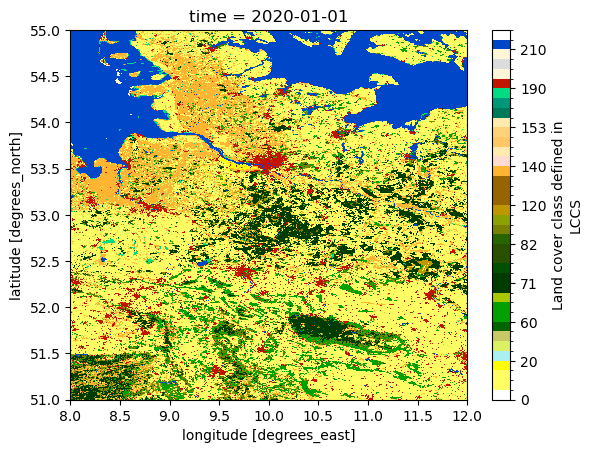

In [9]:
cmap, norm = land_cover_mask.get_cmap()
cube.lccs_class.sel(time="2020-01-01 00:00:00", method="nearest").plot(cmap=cmap, norm=norm)